In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy

In [2]:
t_obs = 1*30*24*60*60.0
nu_range=np.arange(-277.76*10**-6,277.76*10**-6,1/t_obs)
nu_range_custom= np.linspace(-277.76*10**-6,277.76*10**-6,100000)
# np.sinc(3.14*nu_range*t_obs)
# 1/t_obs
nu_range.shape
# 3.14*nu_range*t_obs

(1440,)

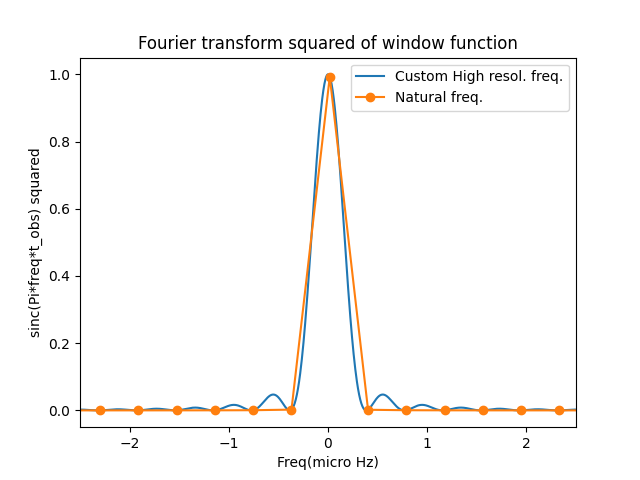

In [3]:
%matplotlib widget
plt.figure()
plt.plot(nu_range_custom*10**6,np.sinc(nu_range_custom*t_obs)**2,label = 'Custom High resol. freq.')
plt.plot(nu_range*10**6,np.sinc(nu_range*t_obs)**2,'-o',label = 'Natural freq.')
plt.ylabel('sinc(Pi*freq*t_obs) squared')
plt.xlabel('Freq(micro Hz)')
plt.title('Fourier transform squared of window function')
plt.legend()
plt.xlim(-2.5,2.5)
plt.show()

In [4]:
def lpeak(x,x0,h,fwhm):
    return h*(fwhm/2)**2/((x-x0)**2+(fwhm/2)**2)


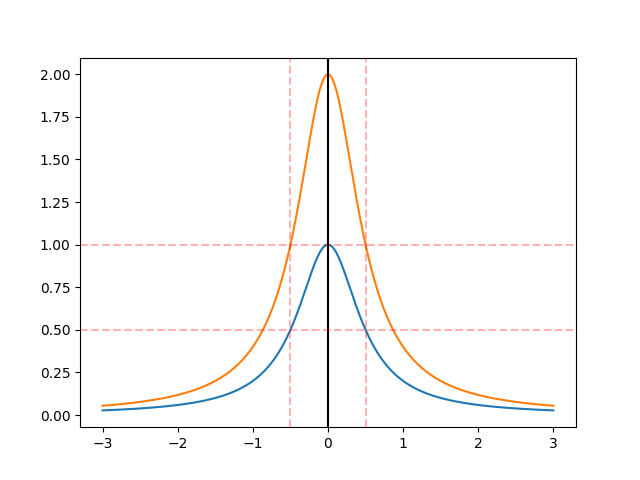

In [5]:
prange = np.linspace(-3,3,400)
plt.figure()
plt.plot(prange,lpeak(prange,0,1,1))
plt.plot(prange,lpeak(prange,0,2,1))
plt.axvline(0,color='k')
plt.axvline(-1/2,color='r',linestyle='--',alpha=0.3)
plt.axvline(1/2,color='r',linestyle='--',alpha=0.3)
plt.axhline(1,color='r',linestyle='--',alpha=0.3)
plt.axhline(1/2,color='r',linestyle='--',alpha=0.3)
plt.show()

In [765]:
def exp_decay(t,a=1,nu0=100*1e-6,tau=np.inf):
    return a*np.exp(-t/tau)*np.sin(2*np.pi*nu0*t)

In [766]:
print(exp_decay(np.array([0,0.2,0.202]),tau=100))
#print(1*np.exp(-0.2/10))

[0.         0.00012541 0.00012666]


In [767]:
1e6/np.pi/0.1/(60*60*24),

(36.841422012012806,)

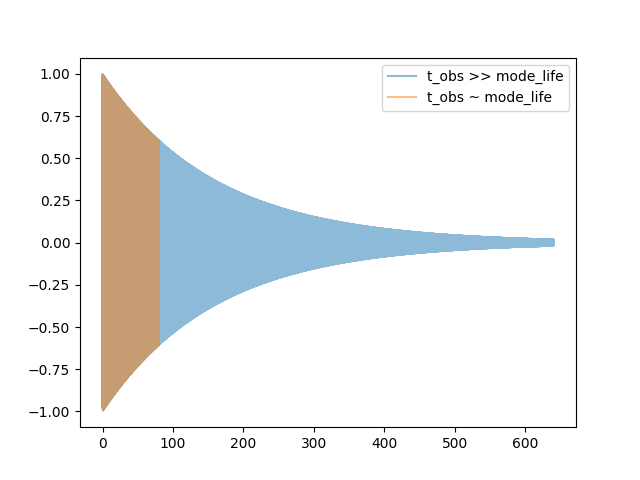

In [1216]:
t_obs2 = 80*24*60*60
samp_factor = 8
t_obs = samp_factor*t_obs2    #365*24*60*60
del_obs = 30*60
t_samp = np.arange(0,t_obs+del_obs,del_obs)
t_samp2 = np.arange(0,t_obs2+del_obs,del_obs)

life_samp = 160*(24*60*60)
signal = exp_decay(t_samp,tau=life_samp)
signal2 = exp_decay(t_samp2,tau=life_samp)
plt.figure()
plt.plot(t_samp/(60*60*24),signal,alpha=0.5,label='t_obs >> mode_life')
plt.plot(t_samp2/(60*60*24),signal2,alpha=0.5,label='t_obs ~ mode_life')
plt.legend()
plt.show()

In [1217]:
t_samp

array([       0,     1800,     3600, ..., 55292400, 55294200, 55296000])

In [1218]:
signal_fft = scipy.fft.fft(signal)
signal_freq = scipy.fft.fftfreq(len(signal),t_samp[-1]/t_samp.shape[0])
signal_freq

array([ 0.00000000e+00,  1.80844907e-08,  3.61689815e-08, ...,
       -5.42534722e-08, -3.61689815e-08, -1.80844907e-08])

In [1219]:
signal2_fft = scipy.fft.fft(signal2)
signal_freq2 = scipy.fft.fftfreq(len(signal2),t_samp2[-1]/t_samp2.shape[0])

In [1220]:
1e6*signal_freq2[(signal_freq2>98/1e6)&(signal_freq2<102/1e6)]

array([ 98.09027778,  98.2349537 ,  98.37962963,  98.52430556,
        98.66898148,  98.81365741,  98.95833333,  99.10300926,
        99.24768519,  99.39236111,  99.53703704,  99.68171296,
        99.82638889,  99.97106481, 100.11574074, 100.26041667,
       100.40509259, 100.54976852, 100.69444444, 100.83912037,
       100.9837963 , 101.12847222, 101.27314815, 101.41782407,
       101.5625    , 101.70717593, 101.85185185, 101.99652778])

In [1221]:
psd = (np.abs(signal_fft)**2)/len(signal)
psd2 = (np.abs(signal2_fft)**2)/len(signal2)

norm_psd = np.sum(np.abs(signal)**2)/(np.sum(psd))
norm_psd2 = np.sum(np.abs(signal2)**2)/(np.sum(psd2))
norm_psd,norm_psd2

(1.0000000000000002, 1.0)

In [1222]:
np.sum(np.abs(signal)**2),np.sum(psd),np.sum(np.abs(signal2)**2),np.sum(psd2)

(1919.355903262564, 1919.3559032625635, 1213.8123652448426, 1213.8123652448426)

In [1223]:
# t_samp_low_res = t_samp[::5]  #Note that this would change the nyquist frequency
# signal_low_res = signal[::5]
# signal_low_res_fft = scipy.fft.fft(signal_low_res)
# signal_low_res_freq = scipy.fft.fftfreq(len(signal_low_res),t_samp_low_res[-1]/t_samp_low_res.shape[0])
# psd_low_res = (np.abs(signal_low_res_fft)**2)/len(signal_low_res)
# norm_psd_low_res = np.sum(np.abs(signal_low_res)**2)/(np.sum(psd_low_res))

In [1224]:
norm_psd_low_res = np.sum(np.abs(signal[::samp_factor])**2)/(np.sum(psd[::samp_factor]))
norm_psd_low_res

0.9027397589926174

In [1225]:
# Reduction in height
amp=1
h_full = (amp**2)*life_samp
h_lim = (t_obs2*(amp)**2)/(t_obs2/life_samp+2)
h_factor = h_lim/h_full

w_factor = 1/np.sqrt(h_factor)
h_full,h_lim,h_factor,w_factor

(13824000, 2764800.0, 0.2, 2.23606797749979)

In [1226]:
def lpeak_seismo(x,x0,h,fwhm):
    return h/(1+4*(fwhm**-2)*(x-x0)**2)

lor_peak = lpeak_seismo(signal_freq,100*1e-6,np.max(norm_psd*psd*t_obs),1/np.pi/life_samp)
lor_peak_lim = lpeak_seismo(signal_freq,100*1e-6,h_factor*np.max(norm_psd*psd*t_obs),w_factor/np.pi/life_samp)
lor_peak2_lim = lpeak_seismo(signal_freq2,100*1e-6,h_factor*np.max(norm_psd*psd*t_obs),w_factor/np.pi/life_samp)
lor_peak.max(),np.max(norm_psd*psd*t_obs)

(16887670335.896826, 23554655354.761776)

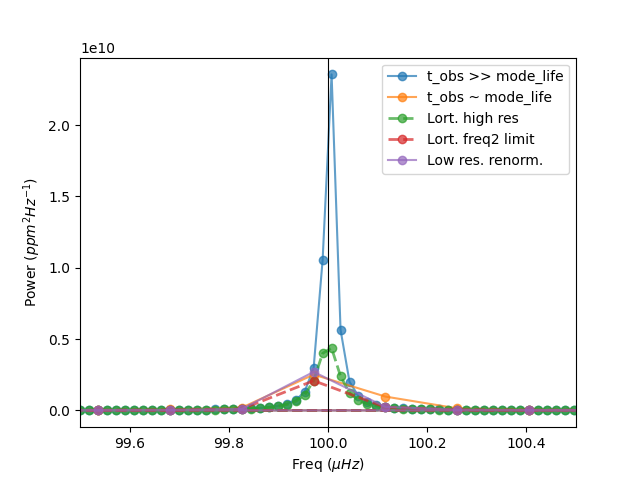

In [1239]:
plt.figure()
plt.plot(signal_freq*1e6,norm_psd*psd*t_obs,'o-',label='t_obs >> mode_life',alpha=0.7)
# plt.plot(signal_freq*1e6,lor_peak,'o--',linewidth=2,label='Lorentzian peak',alpha=0.7)
plt.plot(signal_freq2*1e6,norm_psd2*psd2*t_obs2,'o-',label='t_obs ~ mode_life',alpha=0.7)
plt.plot(signal_freq*1e6,lor_peak_lim,'o--',linewidth=2,label='Lort. high res',alpha=0.7)
plt.plot(signal_freq2*1e6,lor_peak2_lim,'o--',linewidth=2,label='Lort. freq2 limit',alpha=0.7)
# plt.plot(signal_freq[::samp_factor]*1e6,norm_psd*psd[::samp_factor]*t_obs,'o-',label='Low res. noob',alpha=0.7)
plt.plot(signal_freq[::samp_factor]*1e6,norm_psd_low_res*psd[::samp_factor]*t_obs,'o-',label='Low res. renorm.',alpha=0.7)
# plt.plot(signal_freq*1e6,h_factor*norm_psd*psd*t_obs,'o-',label='full with h_factor',alpha=0.7)
# plt.plot(signal_freq2*1e6,norm_psd2*(1/h_factor)*psd2*t_obs2,'o-',label='Low res. h_factor.',alpha=0.7)
plt.axvline(100,linewidth=0.8,color='black')
plt.xlabel(r'Freq ($\mu Hz$)')
plt.ylabel(r'Power ($ppm^{2}Hz^{-1}$)')
plt.xlim(99.5,100.5)
# plt.xlim(0,)
plt.legend()
# plt.tight_layout()
plt.show()

In [713]:
sinc_part = np.sinc(signal_freq2*t_obs2)**2
sinc_part

array([1.00000000e+00, 3.25224089e-32, 3.25224089e-32, ...,
       5.17376116e-32, 3.25224089e-32, 3.25224089e-32])

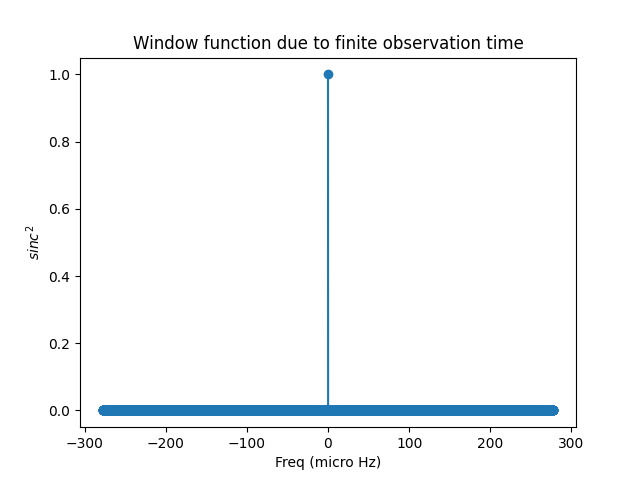

In [714]:
plt.figure()
plt.plot(signal_freq2*1e6,sinc_part,'o-')
# plt.xlim(-1,1)
plt.title('Window function due to finite observation time')
plt.xlabel('Freq (micro Hz)')
plt.ylabel(r'$sinc^2$')
# plt.legend()
plt.show()

In [715]:
psd.shape,psd2.shape,sinc_part.shape

((32257,), (4033,), (4033,))

In [716]:
conv_signal = scipy.signal.convolve(psd,sinc_part,'same')
conv_signal.shape

(32257,)

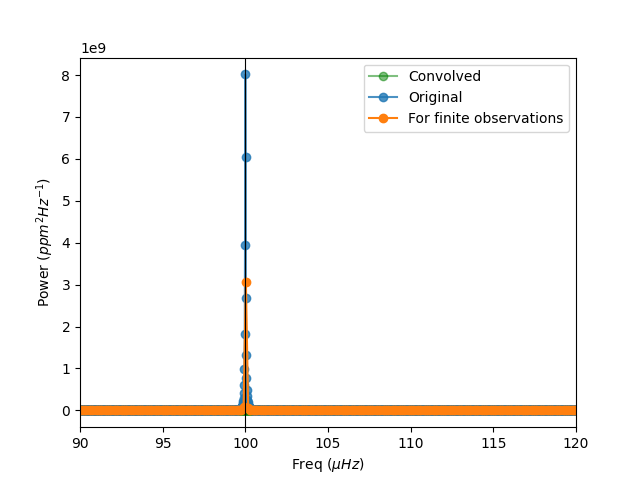

In [717]:
plt.figure()
plt.plot(signal_freq*1e6+68.5,conv_signal*t_obs,'o-',label='Convolved',color='green',alpha=0.5)
#We added the offset to compensate for the shift introduced due to convolution
plt.plot(signal_freq*1e6,norm_psd*psd*t_obs,'o-',label='Original',alpha=0.8)
plt.plot(signal_freq2*1e6,norm_psd2*psd2*t_obs2,'o-',label='For finite observations',alpha=1)
plt.axvline(100,linewidth=0.8,color='black')
plt.xlabel(r'Freq ($\mu Hz$)')
plt.ylabel(r'Power ($ppm^{2}Hz^{-1}$)')
plt.xlim(90,120)
plt.legend()
plt.show()

# Possible solution : Sample every 10th point from a PSD with 10 times the resolution

plt.figure()
plt.plot